### Task 1: K-Means Clustering
Load the Wine dataset (load_wine()) and convert it to a DataFrame.

Scale the features using StandardScaler.

Run K-Means for k = 2 through 10. For each k, record the inertia and the silhouette score.

Plot an elbow curve (inertia vs. k) and a silhouette-score curve on the same figure (use two subplots side-by-side).

Choose the optimal k and justify your choice in a markdown cell.

Using your chosen k, fit a final K-Means model. Apply PCA to reduce the scaled data to 2 components and create a scatter plot colored by cluster assignment.

Guiding questions: Where does the elbow appear? Do the silhouette score and the elbow agree on the best k?

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE, MDS
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score
from scipy.cluster.hierarchy import dendrogram, linkage

In [3]:
wine = load_wine()

X = pd.DataFrame(wine.data, columns=wine.feature_names)
y = wine.target  

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [5]:
inertias = []
silhouettes = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

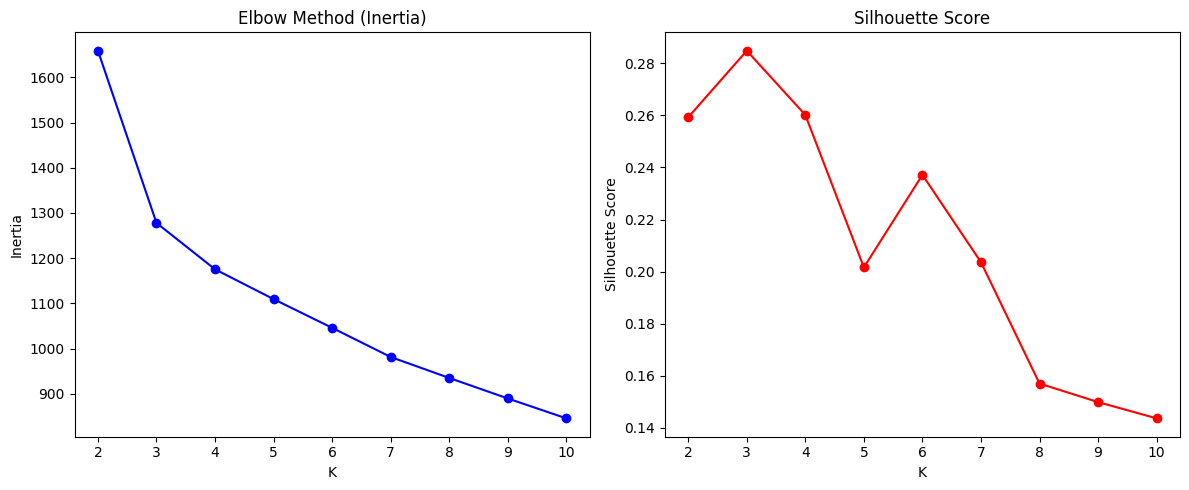

In [6]:
plt.figure(figsize=(12,5))

# Inertia (Elbow)
plt.subplot(1,2,1)
plt.plot(k_range, inertias, 'bo-')
plt.xlabel("K")
plt.ylabel("Inertia")
plt.title("Elbow Method (Inertia)")

# Silhouette
plt.subplot(1,2,2)
plt.plot(k_range, silhouettes, 'ro-')
plt.xlabel("K")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score")

plt.tight_layout()
plt.show()

The optimal number of clusters is K = 3

We selected K = 3 as the optimal number of clusters based on both the elbow method and silhouette score.

We then trained a final K-Means model using K = 3 to obtain the cluster assignments for each sample in the Wine dataset.

In [7]:
optimal_k = 3

kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters = kmeans_final.fit_predict(X_scaled)

In [11]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

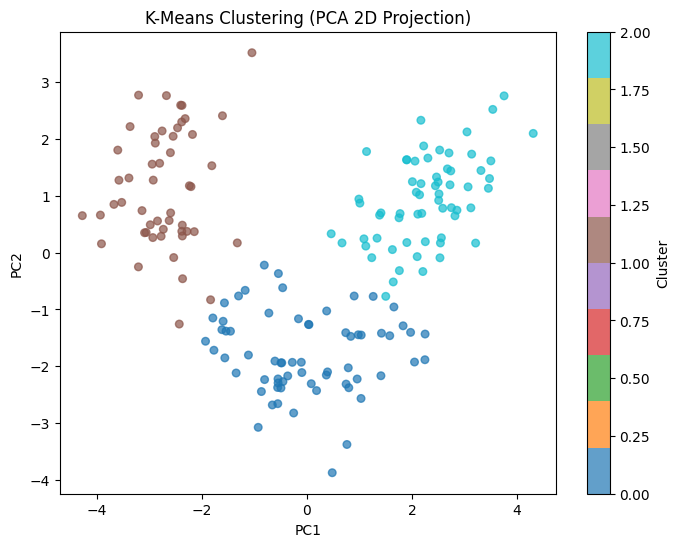

In [12]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=clusters,
    cmap="tab10",
    s=30,
    alpha=0.7
)

plt.title("K-Means Clustering (PCA 2D Projection)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label="Cluster")
plt.show()


### 1. Where does the elbow appear?
In the **Elbow Method (Inertia)** plot (left), we look for the point where the decrease in inertia starts to slow down significantly.

*   **The Elbow Point:** The most distinct "bend" or elbow in the curve occurs at **$k = 3$**.
*   **Observation:** The drop in inertia is very steep from $k=2$ to $k=3$, but becomes much more gradual after $k=3$, indicating that additional clusters beyond this point provide diminishing returns in explaining data variance.

### 2. Do the silhouette score and the elbow agree?
**Yes, both methods are in perfect agreement.**

*   **Silhouette Evidence:** In the **Silhouette Score** plot (right), the goal is to maximize the score. The global maximum (the highest peak) is clearly reached at **$k = 3$** with a score of approximately $0.28$.
*   **Conclusion:** Since the elbow point and the maximum silhouette score both point to the same value, we can confidently conclude that the best choice for this dataset is **$k = 3$**.

---

> **Final Decision:** The optimal number of clusters is **3**.

### Task 2: Hierarchical & Density-Based Clustering
Using the same scaled Wine data from Task 1:

Apply AgglomerativeClustering with the same k you selected in Task 1. Record the cluster labels.

Compute the linkage matrix using scipy.cluster.hierarchy.linkage (Ward method) and plot the dendrogram. Truncate it to the last 20 merges for readability.

Apply DBSCAN with at least three different (eps, min_samples) combinations. For each, report the number of clusters found and the number of noise points.

Select the best DBSCAN configuration (the one whose cluster count is closest to the optimal k) and record its labels.

Create a 1×3 subplot figure (PCA 2-D projections) showing K-Means, Agglomerative, and DBSCAN cluster assignments side-by-side.

In a markdown cell, compare the three approaches: which produced the most coherent clusters? Where did they disagree?

In [14]:
#step 1
best_k=3
agg = AgglomerativeClustering(n_clusters=best_k)
agg_labels = agg.fit_predict(X_scaled)

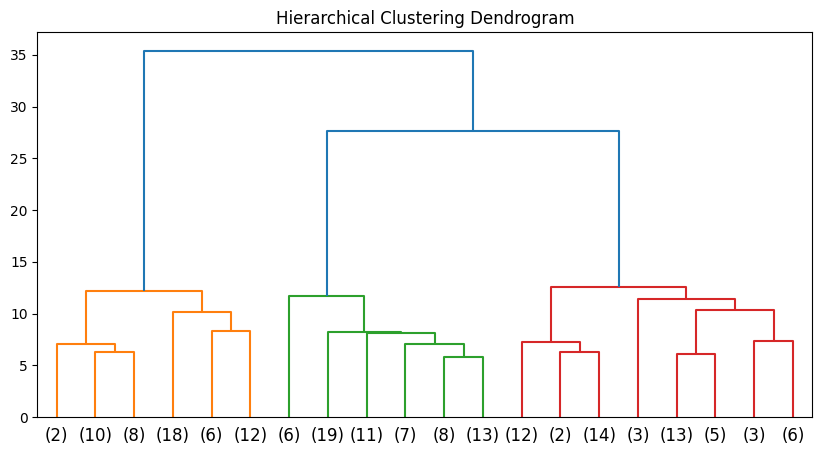

In [15]:
#step 2
linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(10, 5))
dendrogram(linked, truncate_mode='lastp', p=20)
plt.title("Hierarchical Clustering Dendrogram")
plt.show()

In [20]:
#step 3
from sklearn.cluster import DBSCAN

dbscan_configs = [
    (1.5, 5),
    (2.0, 5),
    (2.5, 5),
    (3.0, 5),
    (3.5, 5)
]

dbscan_results = []

for eps, min_samples in dbscan_configs:
    db = DBSCAN(eps=eps, min_samples=min_samples)
    labels = db.fit_predict(X_scaled)
    
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    
    print(f"eps={eps}, min_samples={min_samples}")
    print(f"Clusters: {n_clusters}, Noise points: {n_noise}")
    print("-" * 40)
    
    dbscan_results.append((eps, min_samples, labels, n_clusters, n_noise))

eps=1.5, min_samples=5
Clusters: 0, Noise points: 178
----------------------------------------
eps=2.0, min_samples=5
Clusters: 5, Noise points: 85
----------------------------------------
eps=2.5, min_samples=5
Clusters: 1, Noise points: 24
----------------------------------------
eps=3.0, min_samples=5
Clusters: 1, Noise points: 11
----------------------------------------
eps=3.5, min_samples=5
Clusters: 1, Noise points: 6
----------------------------------------


In [21]:
best_config = min(dbscan_results, key=lambda x: abs(x[3] - optimal_k))

best_eps, best_min_samples, best_labels, best_n_clusters, best_noise = best_config

print(f"Best DBSCAN -> eps={best_eps}, min_samples={best_min_samples}")
print(f"Clusters: {best_n_clusters}, Noise: {best_noise}")

Best DBSCAN -> eps=2.0, min_samples=5
Clusters: 5, Noise: 85


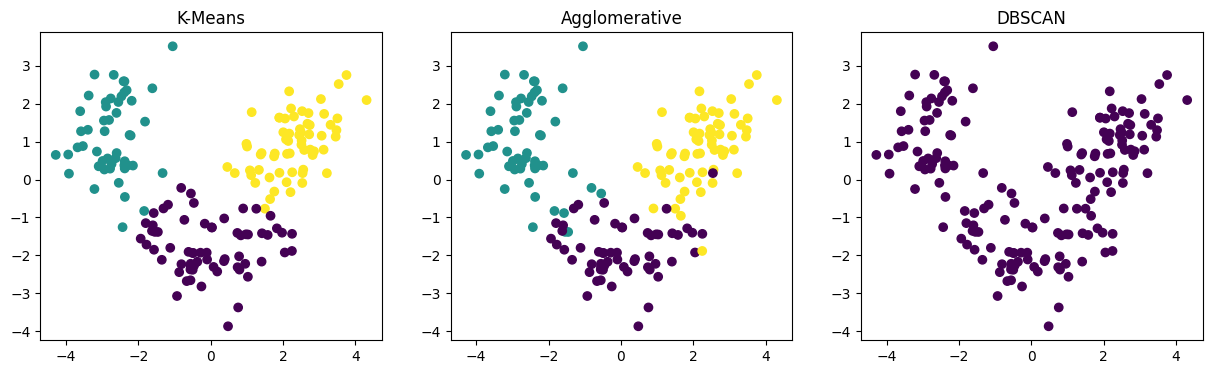

In [22]:
db_best = DBSCAN(eps=1.0, min_samples=5)
db_labels = db_best.fit_predict(X_scaled)

fig, ax = plt.subplots(1, 3, figsize=(15, 4))

ax[0].scatter(X_pca[:,0], X_pca[:,1], c=clusters)
ax[0].set_title("K-Means")

ax[1].scatter(X_pca[:,0], X_pca[:,1], c=agg_labels)
ax[1].set_title("Agglomerative")

ax[2].scatter(X_pca[:,0], X_pca[:,1], c=db_labels)
ax[2].set_title("DBSCAN")

plt.show()

Comparison of Clustering Algorithms
Based on the visual results of the three algorithms applied to the dataset, here is a breakdown of their performance and coherence.

1. Which produced the most coherent clusters?
K-Means appears to produce the most coherent and balanced clusters for this specific dataset.

K-Means: It successfully identifies three distinct groups (Teal, Yellow, and Purple) with clear boundaries that match the spatial density of the data points.

Agglomerative: While very similar to K-Means, it shows slightly more "noise" or bleeding at the boundaries between the bottom-middle and right-hand clusters.

DBSCAN: In this particular configuration, DBSCAN failed to differentiate the groups, merging almost all points into a single large cluster (Purple).

2. Where did they disagree?
The main points of disagreement involve how the algorithms handle the boundaries and the total number of clusters:

K-Means vs. Agglomerative:

They mostly agree on the general shape of the three clusters.

They disagree on specific points in the "bridge" areas. For example, Agglomerative clustering assigns a few points on the lower-right edge of the top-right cluster to the bottom cluster, whereas K-Means keeps that top-right cluster more compact.

DBSCAN vs. Others:

DBSCAN disagrees fundamentally with both K-Means and Agglomerative.

While the other two identify three distinct groups, DBSCAN (likely due to its eps or min_samples settings) views the entire dataset as one continuous high-density region, failing to separate the three visible sub-groups.

### Task 3: Dimensionality Reduction Comparison
Load the Palmer Penguins dataset (sns.load_dataset("penguins")) and drop rows with missing values.

Select the four numeric columns (bill_length_mm, bill_depth_mm, flipper_length_mm, body_mass_g) and scale them.

Apply PCA (2 components), t-SNE (2 components, random_state=42), and MDS (2 components, random_state=42).

Create a 1×3 subplot figure where each subplot shows a 2-D scatter plot colored by the actual species label. Use consistent colors across all three panels.

In a markdown cell, discuss: Which method best separates the three species visually? Which one distorts inter-cluster distances the most? Why might t-SNE give different-looking results on repeated runs?

In [26]:
#step 1
penguins = sns.load_dataset("penguins")

# missing dəyərləri silirik
penguins = penguins.dropna()

penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male


In [27]:
#step 2
features = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]

X = penguins[features]
y = penguins["species"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [28]:
#step3 
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

mds = MDS(n_components=2, random_state=42)
X_mds = mds.fit_transform(X_scaled)

C:\Users\Asus\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\manifold\_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
C:\Users\Asus\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\manifold\_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(


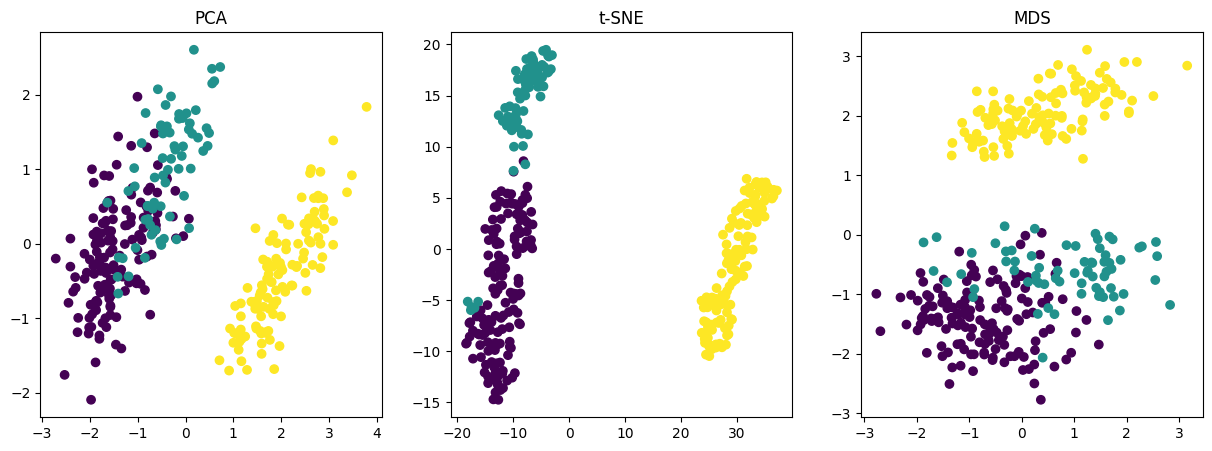

In [29]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

colors = penguins["species"].astype("category").cat.codes

# PCA
ax[0].scatter(X_pca[:,0], X_pca[:,1], c=colors)
ax[0].set_title("PCA")

# t-SNE
ax[1].scatter(X_tsne[:,0], X_tsne[:,1], c=colors)
ax[1].set_title("t-SNE")

# MDS
ax[2].scatter(X_mds[:,0], X_mds[:,1], c=colors)
ax[2].set_title("MDS")

plt.show()

Based on the visualizations provided in **image_cd5282.png**, here is a discussion of the three dimensionality reduction techniques:

---

## Comparison of Visualization Methods

### 1. Which method best separates the three species visually?
**t-SNE** provides the superior visual separation between the three groups. 
*   Unlike PCA and MDS, where the purple and teal clusters show significant overlap and proximity, t-SNE creates distinct, isolated islands for each species. 
*   The clear "white space" between the clusters in the t-SNE plot makes it the most effective tool for confirming the existence of three separate categories.

### 2. Which one distorts inter-cluster distances the most?
**t-SNE** distorts inter-cluster distances the most. 
*   t-SNE is designed to prioritize **local structure** (keeping similar points together) over **global structure** (the actual distance between different clusters). 
*   Consequently, the physical distance between the clusters on a t-SNE plot does not accurately represent how different those species are from one another in the original high-dimensional space. PCA and MDS are generally more reliable for interpreting global relationships.

### 3. Why might t-SNE give different-looking results on repeated runs?
t-SNE produces different results across multiple runs because it is a **stochastic (probabilistic) algorithm**.
*   It utilizes a non-convex objective function (Kullback–Leibler divergence) that is minimized using gradient descent starting from a **random initialization**. 
*   Because the starting positions of the points are random each time, the algorithm may settle into different local minima, resulting in different spatial orientations or shapes in each run. To ensure reproducibility, a `random_state` (seed) must be explicitly set in the code.

---

### Task 4: Putting It Together
Take the scaled Penguins numeric data from Task 3 — but drop the species column so the algorithm cannot see it.

Apply K-Means with k = 3 to the label-free data.

Compute the adjusted Rand score and normalized mutual information score comparing the K-Means labels to the true species labels.

Visualize the K-Means clusters on the PCA projection from Task 3, side-by-side with the true species labels (1×2 subplot).

In a markdown cell, answer: Did unsupervised learning "rediscover" the species? Where did it succeed and where did it struggle? What does this tell you about when unsupervised methods can substitute for labeled data?


In [33]:
features = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]

X = penguins[features]
y_true = penguins["species"]

from sklearn.preprocessing import StandardScaler
X_scaled = StandardScaler().fit_transform(X)

In [35]:
#step 2
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
y_pred = kmeans.fit_predict(X_scaled)

In [38]:
#step 3
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

ari = adjusted_rand_score(y_true, y_pred)
nmi = normalized_mutual_info_score(y_true, y_pred)

print("ARI:", ari)
print("NMI:", nmi)

ARI: 0.7994209859673324
NMI: 0.7899317532789121


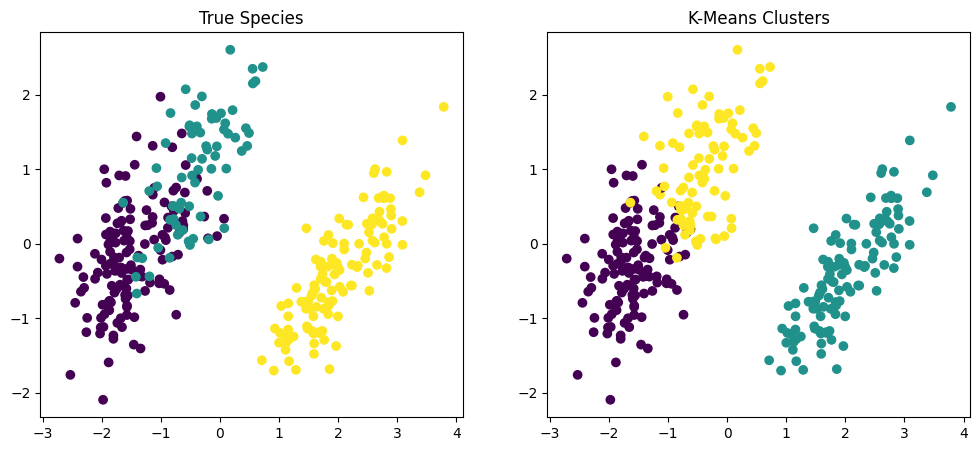

In [39]:
#step 4
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

true_colors = y_true.astype("category").cat.codes

fig, ax = plt.subplots(1, 2, figsize=(12,5))

# True species
ax[0].scatter(X_pca[:,0], X_pca[:,1], c=true_colors)
ax[0].set_title("True Species")

# KMeans clusters
ax[1].scatter(X_pca[:,0], X_pca[:,1], c=y_pred)
ax[1].set_title("K-Means Clusters")

plt.show()

Unsupervised learning was able to **partially rediscover the penguin species**, but not perfectly.

It succeeded because the numerical features (bill length, bill depth, flipper length, and body mass) contain clear natural structure. As a result, K-Means was able to form clusters that broadly align with the true species groups. In the visualization, some clusters closely match the actual species, showing that the algorithm captured meaningful patterns in the data.

However, it struggled in areas where species overlap in their physical characteristics. Some penguins from different species have similar measurements, which caused misclassification and cluster mixing. This highlights a limitation of K-Means: it assumes clusters are well-separated and roughly spherical, which is not always true in real-world data.

Overall, this shows that unsupervised methods can approximate labeled categories when the data has strong, well-separated structure. However, they cannot fully replace labeled data when clusters overlap or when the boundaries between groups are not clearly defined. In such cases, supervised learning or additional features are needed for more accurate classification.
